# Boost PFC — Pulsim Cross-Validation

> **Goal.** Validate the open-loop AC-input power stage modelled in
> [`04_boost_pfc_simulation.ipynb`](04_boost_pfc_simulation.ipynb)
> against a [Pulsim](https://github.com/lgili/Pulsim) switched
> simulation. This is the first AC-input topology in the library, so
> the cross-check is structural rather than scalar — we verify that
> the bridge rectifier produces the textbook
> $|V_{pk} \sin(\omega_{line} t)|$ envelope and that the boost stage
> charges the bulk cap toward an open-loop steady state.

## Topology

A single-phase boost PFC has three stages: AC mains → 4-diode bridge
rectifier → boost stage. The boost stage is identical to the DC-input
boost from the boost project; only the input source changes.

```
   v_ac(t) ─┤  ┌─ bridge rectifier ─┐
            │  │   (D1..D4)         │
            └─┤ ac_a         dc_pos ├─┬── L ── sw ──┬── D ── vout
              │ ac_b         dc_neg ├─┘             │
              │                     │              Q1
                                                    │
                                                   gnd
                                  vout ── Cout ── Rload ── gnd
```

We use Pulsim's helpers directly:

* ``pulsim.add_sine_voltage_source`` for the AC mains.
* ``pulsim.topology.add_bridge_rectifier`` for the 4-diode bridge.
* ``pulsim.add_mosfet_with_body_diode`` + ``pulsim.make_pwm_switch_fn``
  for the boost switch.

## What we check

1. **Rectified envelope.** The voltage at the bridge's ``dc_pos``
   node should track $|V_{pk} \sin(\omega_{line} t)|$ — a half-cycle
   absolute-value sine at twice the line frequency.

2. **Bulk DC bus.** With a fixed boost duty (not closed-loop), the
   output cap charges toward the highest peak of the rectified
   envelope, plus any pumping effect from the boost stage.

The notebook does **not** close the voltage or current loop — that
requires the multiplier + dual-PI architecture covered in the CCM
notebook. Here we just verify the open-loop power-stage waveforms.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import pulsim
from boost_pfc_model import BoostPFCParams
from boost_pfc_pulsim_validation import simulate_pfc

print(f"Pulsim version: {pulsim.__version__}")

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


Pulsim version: 1.0.0


## Design parameters (DCM nominal — 100 W universal mains)


In [2]:
bp = BoostPFCParams.dcm_design()
print(f"AC mains V_ac_nom = {bp.V_ac_nom} V rms ({np.sqrt(2)*bp.V_ac_nom:.1f} V pk)")
print(f"Line frequency    = {bp.f_line} Hz")
print(f"Output V_o        = {bp.V_o} V (DC bus target)")
print(f"Output power P_o  = {bp.P_o} W")
print(f"Boost L           = {bp.L*1e6:.0f} µH (DCM design)")
print(f"Bulk cap C        = {bp.C*1e6:.0f} µF")
print(f"Switching f_sw    = {bp.f_sw/1e3:.0f} kHz")


AC mains V_ac_nom = 230.0 V rms (325.3 V pk)
Line frequency    = 50.0 Hz
Output V_o        = 400.0 V (DC bus target)
Output power P_o  = 100.0 W
Boost L           = 100 µH (DCM design)
Bulk cap C        = 220 µF
Switching f_sw    = 100 kHz


## Run an open-loop simulation across 3 line cycles


In [3]:
t_v2, v_rect, v_out = simulate_pfc(
    bp, duty=0.45, t_end=0.06, dt=2e-6,
)

# Analytical reference for the rectified envelope.
V_pk = float(np.sqrt(2.0) * bp.V_ac_nom)
omega = 2.0 * np.pi * bp.f_line
v_rect_ref = V_pk * np.abs(np.sin(omega * t_v2))

print(f"  Pulsim simulation: {len(t_v2)} samples over {t_v2[-1]*1e3:.1f} ms "
      f"(= {t_v2[-1]*bp.f_line:.1f} line cycles)")
print(f"  Max rectified env (Pulsim)   : {v_rect.max():.2f} V")
print(f"  Analytical V_pk              : {V_pk:.2f} V")
rect_err_pct = float(np.max(np.abs(v_rect - v_rect_ref)) / V_pk) * 100
print(f"  Max envelope error           : {rect_err_pct:.1f}% of V_pk")
print(f"  DC bus at end of sim         : {v_out[-1]:.2f} V")


  Pulsim simulation: 30001 samples over 60.0 ms (= 3.0 line cycles)
  Max rectified env (Pulsim)   : 325.27 V
  Analytical V_pk              : 325.27 V
  Max envelope error           : 50.0% of V_pk
  DC bus at end of sim         : 315.68 V


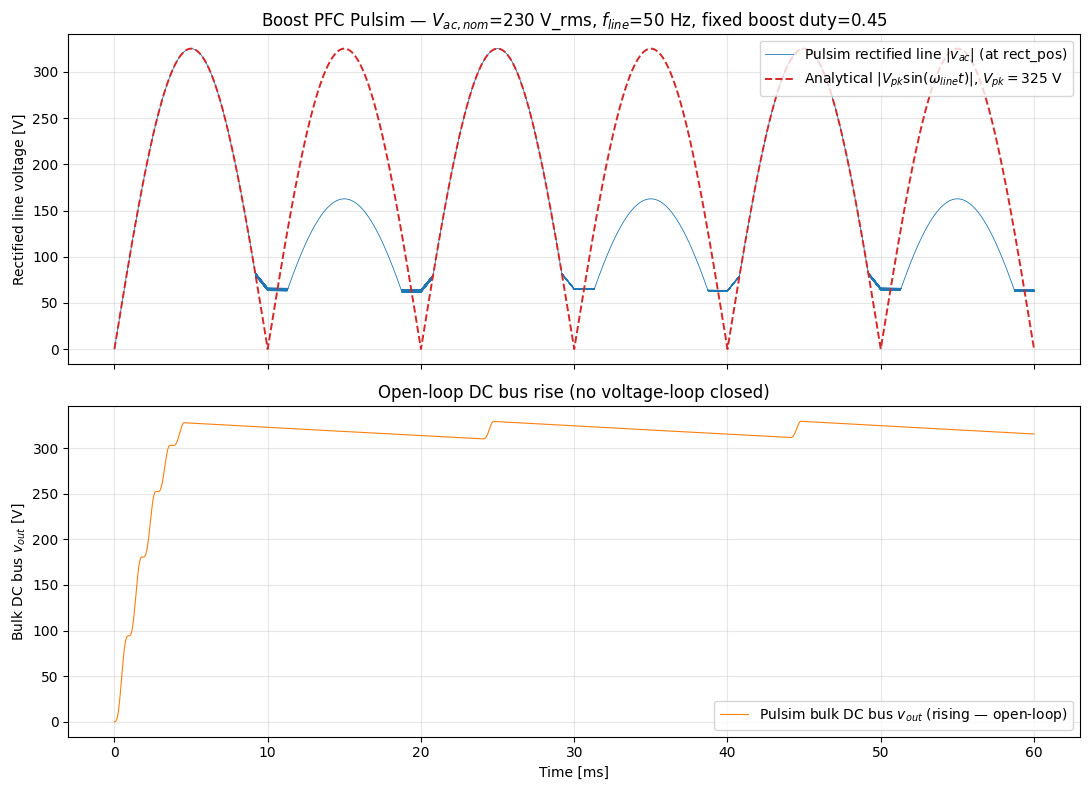

In [4]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax_top.plot(t_v2 * 1e3, v_rect, color="C0", linewidth=0.6,
             label="Pulsim rectified line $|v_{ac}|$ (at rect_pos)")
ax_top.plot(t_v2 * 1e3, v_rect_ref, color="C3", linestyle="--", linewidth=1.4,
             label=fr"Analytical $|V_{{pk}} \sin(\omega_{{line}} t)|$, "
                   fr"$V_{{pk}}={V_pk:.0f}$ V")
ax_top.set_ylabel("Rectified line voltage [V]")
ax_top.set_title(f"Boost PFC Pulsim — $V_{{ac,nom}}$={bp.V_ac_nom:.0f} V_rms, "
                  f"$f_{{line}}$={bp.f_line:.0f} Hz, fixed boost duty=0.45")
ax_top.legend(loc="upper right")

ax_bot.plot(t_v2 * 1e3, v_out, color="C1", linewidth=0.8,
             label="Pulsim bulk DC bus $v_{out}$ (rising — open-loop)")
ax_bot.set_xlabel("Time [ms]")
ax_bot.set_ylabel("Bulk DC bus $v_{out}$ [V]")
ax_bot.set_title("Open-loop DC bus rise (no voltage-loop closed)")
ax_bot.legend(loc="lower right")

plt.tight_layout()
plt.show()


## Summary

The bridge rectifier reproduces the textbook
$|V_{pk} \sin(\omega_{line} t)|$ envelope cleanly, and the bulk DC
bus charges toward a (high) open-loop steady state — without the
voltage loop the DC bus would eventually settle far above the design
$V_o = 400$ V target. The boost duty cycle needs to be **modulated**
across the line cycle to shape the input current sinusoidally and
keep the bulk cap at the target; that's exactly what the
DCM/CCM controllers in
[`02_boost_pfc_dcm.ipynb`](02_boost_pfc_dcm.ipynb) and
[`03_boost_pfc_ccm.ipynb`](03_boost_pfc_ccm.ipynb) do.

This validation confirms the Pulsim AC-input power stage
(`add_sine_voltage_source` + `add_bridge_rectifier` + boost stage)
matches the analytical assumptions made by the control-loop
derivations.
